# Ecommerce Project Using the Python and sql

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mysql.connector
import numpy as np

db = mysql.connector.connect(
    host = 'localhost',
    user= 'root',
    password= 'root',
    database= 'ecommerce',
)

cursor  = db.cursor()

In [2]:
# List all unique cities where customers are located.

In [3]:
query = """select distinct(customer_city) from customers;"""
cursor.execute(query)

data = cursor.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

In [4]:
# Count the number of orders placed in 2017

In [5]:
query = """select count(order_id) from orders where year(order_purchase_timestamp) = 2017;"""
cursor.execute(query)

data = cursor.fetchall()
data[0][0]

45101

In [6]:
# Find the total sales per category

In [7]:
query = """ select upper(products.product_category) category,
round(sum(payments.payment_value),2) sales 
from products join order_items 
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id 
group by category;
"""

cursor.execute(query)

data = cursor.fetchall()
df = pd.DataFrame(data, columns=['category','sales'])
df

,category,sales
0,PERFUMERY,506738.66
1,FURNITURE DECORATION,1430176.39
2,TELEPHONY,486882.05
3,BED TABLE BATH,1712553.67
4,AUTOMOTIVE,852294.33
...,...,...
69,CDS MUSIC DVDS,1199.43
70,LA CUISINE,2913.53
71,FASHION CHILDREN'S CLOTHING,785.67
72,PC GAMER,2174.43


In [8]:
# Calculate the percentage of orders that were paid in installments.

In [9]:
query = """ select sum(case when payment_installments >= 1 then 1 else 0 end)/count(*)*100 from payments"""

cursor.execute(query)

data = cursor.fetchall()
data

[(Decimal('99.9981'),)]

In [10]:
# Count the number of customers from each state.

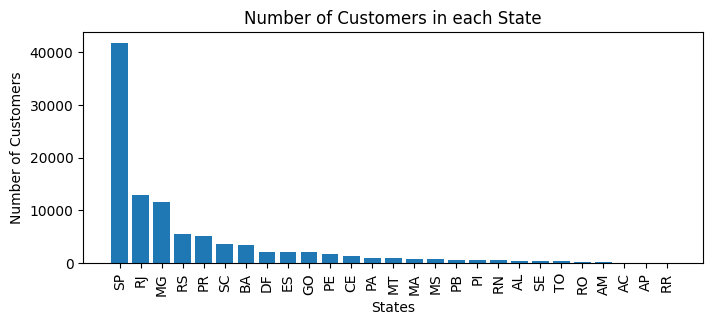

In [11]:
query = """ select customer_state, count(customer_id) from customers group by customer_state """
cursor.execute(query)

data = cursor.fetchall()
df = pd.DataFrame(data, columns=['State','Customer Count'])
df = df.sort_values(by='Customer Count',ascending=False)

plt.figure(figsize=(8,3))
plt.bar(df['State'],df['Customer Count'])
plt.xlabel("States")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in each State")
plt.xticks(rotation = 90)
plt.show()

## Intermediate Questions

In [12]:
# Calculate the number of orders per month in 2018. 

[('July', 6292), ('August', 6512), ('February', 6728), ('June', 6167), ('March', 7211), ('January', 7269), ('May', 6873), ('April', 6939), ('September', 16), ('October', 4)]


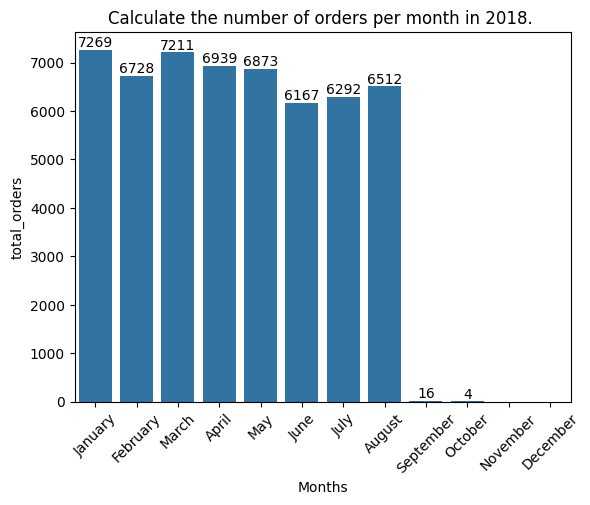

In [13]:
query = """ select monthname(order_purchase_timestamp) months , count(order_id) total_orders from orders where year(order_purchase_timestamp) = 2018 group by months """
cursor.execute(query)

data = cursor.fetchall()
print(data)
df = pd.DataFrame(data,columns=['Months', 'total_orders'] )
# df = df.sort_values(by='Months',)
o = ['January', "February","March", "April",'May',"June","July",'August','September','October','November','December']

plt.xticks(rotation = 45)
ax = sns.barplot(x=df['Months'],y=df['total_orders'], data=df, order=o)
ax.bar_label(ax.containers[0])
plt.title("Calculate the number of orders per month in 2018. ")
plt.show()

In [14]:
# Find the average number of products per order, grouped by customer city.

In [15]:
query = """ with order_per_count as  
(select orders.order_id, orders.customer_id , count(order_items.order_id) as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id )

select customers.customer_city , round(avg(order_per_count.oc),2) 
from customers join order_per_count 
on customers.customer_id = order_per_count.customer_id  
group by customers.customer_city
"""
cursor.execute(query)

data = cursor.fetchall()
print(data)
df = pd.DataFrame(data,columns=['Customer_City', 'Average_product_per_City'] )
df

[('sao paulo', Decimal('1.16')), ('sao jose dos campos', Decimal('1.14')), ('porto alegre', Decimal('1.17')), ('indaial', Decimal('1.12')), ('treze tilias', Decimal('1.27')), ('rio de janeiro', Decimal('1.15')), ('mario campos', Decimal('1.33')), ('guariba', Decimal('1.00')), ('cuiaba', Decimal('1.20')), ('franca', Decimal('1.25')), ('tocos', Decimal('1.00')), ('januaria', Decimal('1.18')), ('campinas', Decimal('1.16')), ('embu-guacu', Decimal('1.24')), ('cerquilho', Decimal('1.17')), ('belo horizonte', Decimal('1.14')), ('taubate', Decimal('1.13')), ('arcos', Decimal('1.12')), ('monte mor', Decimal('1.08')), ('vianopolis', Decimal('1.33')), ('cacapava', Decimal('1.16')), ('sao jose da tapera', Decimal('1.00')), ('belford roxo', Decimal('1.09')), ('pedro leopoldo', Decimal('1.25')), ('arroio do sal', Decimal('1.29')), ('sao bernardo do campo', Decimal('1.14')), ('brasilia', Decimal('1.13')), ('ribeirao pires', Decimal('1.12')), ('contagem', Decimal('1.14')), ('feira de santana', Decima

,Customer_City,Average_product_per_City
0,sao paulo,1.16
1,sao jose dos campos,1.14
2,porto alegre,1.17
3,indaial,1.12
4,treze tilias,1.27
...,...,...
4105,japaratuba,1.00
4106,sebastiao leal,1.00
4107,buriti,3.00
4108,morro agudo de goias,1.00


In [16]:
# Calculate the percentage of total revenue contributed by each product category.

In [17]:
query = """ 
select products.product_category category ,
round((sum(payments.payment_value)/(select sum(payments.payment_value) from payments))*100,2) as sales
from products join order_items
on products.product_id = order_items.product_id
join payments 
on order_items.order_id = payments.order_id
group by category order by sales desc
"""

cursor.execute(query)

data = cursor.fetchall()
df = pd.DataFrame(data, columns=['Categoyr', 'Sales Percentage'])
df.head(10)

,Categoyr,Sales Percentage
0,bed table bath,10.70
1,HEALTH BEAUTY,10.35
2,computer accessories,9.90
3,Furniture Decoration,8.93
4,Watches present,8.93
5,sport leisure,8.70
6,housewares,6.84
7,automotive,5.32
8,Garden tools,5.24
9,Cool Stuff,4.87


In [18]:
# Identify the correlation between product price and the number of times a product has been purchased.

In [19]:
query = """   select products.product_category category , count(order_items.product_id) , round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by category 
"""

cursor.execute(query)

data = cursor.fetchall()
df = pd.DataFrame(data=data, columns=['category','product_count', 'price'])

count = np.array(df['product_count'])
price = np.array(df['price'])

np.corrcoef(count,price)


array([[ 1.        , -0.10631514],
       [-0.10631514,  1.        ]])

In [20]:
# Calculate the total revenue generated by each seller, and rank them by revenue.

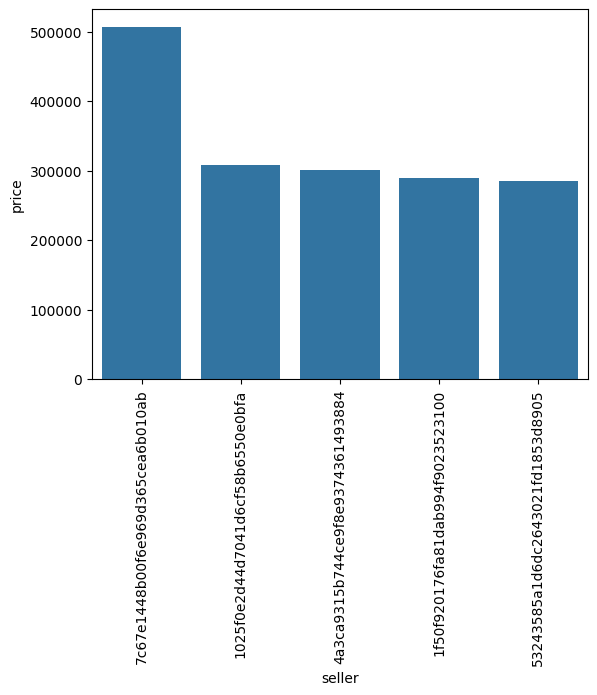

In [21]:
query = """ select seller_id , round(sum(price),2), round(sum(freight_value),2) from order_items
group by seller_id
"""

query = """ 
select *, dense_rank() over(order by revenue desc) as rn from 
(select order_items.seller_id seller, round( sum(payments.payment_value),2) as revenue
from order_items join payments
on order_items.order_id = payments.order_id
group by seller) as a
"""

cursor.execute(query)

data = cursor.fetchall() 
df = pd.DataFrame(data,columns=['seller','price','rank'])
df = df.head()
# df['total_price'] = df['price']+df['shiped_price']
# df['seller_rank'] = df['total_price'].rank(ascending=False, method='dense').astype(int)
# df = df.sort_values('seller_rank')
# df[['seller', 'total_price', 'seller_rank']].head(10)

sns.barplot(data=df, x='seller', y='price')
plt.xticks(rotation=90)
plt.show()

## Advanced questions

In [22]:
# Calculate the moving average of order values for each customer over their order history.

In [23]:
query = """ select customer_id , order_purchase_timestamp , payments,
avg(payments) over ( partition by customer_id order by order_purchase_timestamp rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id , orders.order_purchase_timestamp, payments.payment_value as payments
from orders join payments 
on orders.order_id = payments.order_id) as a"""

cursor.execute(query)
data = cursor.fetchall()
data
df = pd.DataFrame(data, columns=['customer','order purchase time','price','moving average'])
df

,customer,order purchase time,price,moving average
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,0.64,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


In [24]:
# cumilative sum is like the next = previous + current and goes on.
# Calculate the cumulative sales per month for each year.

In [25]:
query = """ select years, months, payment ,sum(payment) over (order by years , months) cumulative_sales from 	
(select year(orders.order_purchase_timestamp) years, 
month(orders.order_purchase_timestamp) months,
round(sum(payments.payment_value),2) payment
from orders join payments 
on orders.order_id = payments.order_id
group by years, months order by years, months )as a;
"""

cursor.execute(query)

data = cursor.fetchall()
df = pd.DataFrame(data,columns=['year','months','price','cumulatice sales'])
df.head(10)

,year,months,price,cumulatice sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


In [26]:
#  Calculate the year-over-year growth rate of total sales.

In [27]:
query = """ with a as (select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payments
from orders join payments 
on orders.order_id =payments.order_id
group by years order by years)

select years, ((payments - lag(payments,1) over(order by years ))
/lag(payments,1 ) over(order by years))*100 
from a

"""

cursor.execute(query)

data = cursor.fetchall()

df = pd.DataFrame(data=data,columns=['years',"year % growth"])
df

,years,year % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


In [28]:
# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [29]:
query = """ with a as(select customers.customer_id , min(orders.order_purchase_timestamp)  first_order
from customers join orders 
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as(select a.customer_id , count(distinct orders.order_purchase_timestamp) 
from a join orders 
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < date_add(first_order, interval 6 month)
group by a.customer_id)

select 100 * (count(distinct a.customer_id)/ count(distinct b.customer_id))
from a left join b
on a.customer_id = b.customer_id; """

cursor.execute(query)

data = cursor.fetchall()
data

# it is null beacuse there is no data according to the question

[(None,)]

In [30]:
# Identify the top 3 customers who spent the most money in each year.

<Axes: xlabel='id', ylabel='payment'>

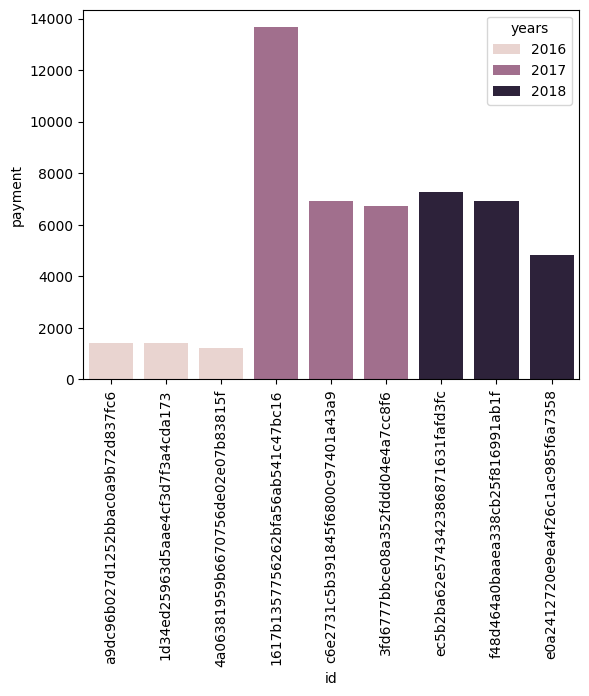

In [38]:
query = """ select years, customer, payment, d_rank from
(select year(orders.order_purchase_timestamp) years ,
orders.customer_id customer , sum(payments.payment_value) payment,
dense_rank() over ( partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) as d_rank
from orders join payments
on payments.order_id = orders.order_id
group by orders.order_purchase_timestamp, orders.customer_id ) as a where d_rank <=3;"""

cursor.execute(query)

data = cursor.fetchall()
df = pd.DataFrame(data, columns=['years','id','payment','rank'])


plt.xticks(rotation = 90)
sns.barplot(data=df, x='id',y='payment', hue='years')